# GDL - Midterm n.1
**Student ID: 714739** (Your student "matricola" goes here)

**Submission ID: 5** (The ID from the sheet circulated in classroom goes here)

In the first midterm assignment, you are required to implement a Gaussian Mixture Model (GMM) and the Expectation-Maximization (EM) algorithm. You are allowed to use `numpy` and other non-machine learning libraries, e.g., `pandas`, `matplotlib`.

**Assumptions.** To ease the implementation, we assume, for each Gaussian distribution in the mixture $\mathcal{N}(\mu_k, \Sigma_k)$, that the *covariance matrix is diagonal*. Furthermore, keep in mind that a good implementation of the EM algorithm provides monotonically increasing log-likelihood, *but* can get stuck in local minima; initialization strategies are fundamental (random? sample points? k-means++?).

**Hyperparameter $k$.** When using a GMM, you should ask yourself: *how many mixtures will be in the data?* You can *maximize* the Bayesian Information Criterion (BIC) to select the number of categories $k$ on your training set. Formally,
$$
\text{BIC}
=
\log P(X\mid \theta) - \frac{|\theta|}{2}\log n,
$$
where $n$ is the number of samples in the training set, $\theta=\{\pi,\mu,\sigma\}$ the parameters of the GMM and $|\theta|$ the number of parameters, i.e., the sum of the number of parameters in $\pi$, $\mu$, and $\sigma$ (*hint*: it also depends on the dimensionality of data $d$!).

**Summary.** Overall, you are required to:
1.  **Implement the GMM class**. Fill the `log_likelihood(samples)`.
2. **Implement the EM algorithm**. Fill the `fit(samples)` method to fit the parameters of a GMM.
3. **Implement the BIC score**. Fill the `bic(samples)` method to perform model selection.
4. **Run training and evaluation**. Select the best scoring model using BIC (Bayesian Information Criterion) for values of $k=\{1,\ldots,6\}$.

**Evaluation.** Your solution will be tested against an hidden test set. For your learning experience, we require you to refrain from using LLM generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 3 and 4 of the notebook.**

### 1. Libraries

In [2]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Gaussian Mixture Model (GMM)

Feel free to play around the implementation. **For evaluation purposes**, the class **must** expose the following attributes and methods:
- `_pi: np.ndarray`
- `_mu: np.ndarray`
- `_sigma: np.ndarray`
- `fit(samples: np.ndarray)`
- `bic(samples: np.ndarray) -> np.ndarray`
- `log_likelihood(samples: np.ndarray) -> np.ndarray`

In [3]:
class GaussianMixtureModel:
    def __init__(self, n_categories: int, n_features: int):
        self.n_categories = n_categories

        # Choose a smart initialization strategy for the parameters!
        # weights (pi), means (mu), covariances (sigma)
        # NOTE: for the covariance, you can store only the diagonal
        self._pi = None # Shape: (n_categories,)
        self._mu = None   # Shape: (n_categories, n_features)
        self._sigma = None # Shape: (n_categories, n_features)

    def log_likelihood(self, samples: np.ndarray) -> np.ndarray:
        d = samples.shape[1] #number of features
        ll = 0
        for x in samples:
            mixture_prob = 0
            for m in range(self.n_categories):
                sigma = self._sigma[m]
                mu = self._mu[m]
                #gaussian density
                coeff = 1 / np.sqrt((2*np.pi)**d * np.prod(sigma)) #normalization term
                exponent = -0.5 * np.sum((x - mu)**2 / sigma) #quadratic term
                gaussian = coeff * np.exp(exponent)

                mixture_prob += self._pi[m] * gaussian #weighted mixture
            ll += np.log(mixture_prob) #log-likelihood
        return np.array(ll)

    def fit(self, samples: np.ndarray):
        N, d = samples.shape
        k = self.n_categories

        #initialization
        self._pi = np.ones(k) / k #uniform
        self._mu = samples[np.random.permutation(N)[:k]] #random means from data
        self._sigma = np.ones((k, d)) #initial diagonal covariance

        history = []
        def e_step():
            responsibilities = np.zeros((N, k))
            for i in range(N):
                x = samples[i]
                for m in range(k):
                    sigma = self._sigma[m]
                    mu = self._mu[m]
                    #compute gaussian probability for component m
                    coeff = 1 / np.sqrt((2*np.pi)**d * np.prod(sigma))
                    exponent = -0.5 * np.sum((x - mu)**2 / sigma)
                    responsibilities[i, m] = self._pi[m] * coeff * np.exp(exponent)
                responsibilities[i] /= np.sum(responsibilities[i]) #scale values so they sum to 1
            return responsibilities

        def m_step(responsibilities):
            counts = np.sum(responsibilities, axis=0)
            self._pi = counts / N

            for m in range(k):
                self._mu[m] = np.sum(responsibilities[:, m].reshape(-1,1) * samples, axis=0) / counts[m] #update mean
                #update variance diagonal
                diff = samples - self._mu[m]
                self._sigma[m] = np.sum(responsibilities[:, m].reshape(-1,1) * diff**2, axis=0) / counts[m]
        epsilon = 1e-4
        previous_ll = 0
        max_iter = 40
        for _ in range(max_iter):
            responsibilities = e_step()
            m_step(responsibilities)

            current_ll = self.log_likelihood(samples)
            history.append(current_ll)
            #check if change is small
            change = abs(current_ll - previous_ll)
            if change < epsilon:
                break
            previous_ll = current_ll
            

        plt.plot(history, marker='o')
        plt.xlabel("iteration")
        plt.ylabel("Log-Likelihood")
        plt.title(f"k={self.n_categories}")
        plt.show()

    def bic(self, samples: np.ndarray) -> np.ndarray:
        N, d = samples.shape
        ll = self.log_likelihood(samples)
        k = self.n_categories
        n_params = (k - 1) + 2 * k * d
        bic = ll - (n_params / 2) * np.log(N) #score

        return np.array(bic)

### 3. Training

Trains the model for increasing number of categories and selects the best scoring one in terms of BIC score.

train.csv loaded successfully. n=800, d=5


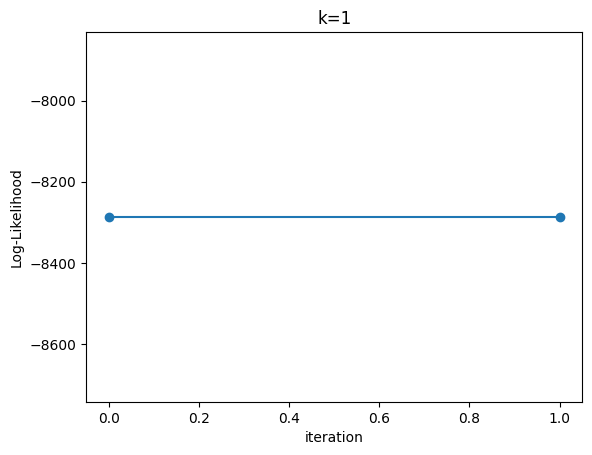

k=1	BIC=-8320.1771	logP(X|θ)=-8286.7541


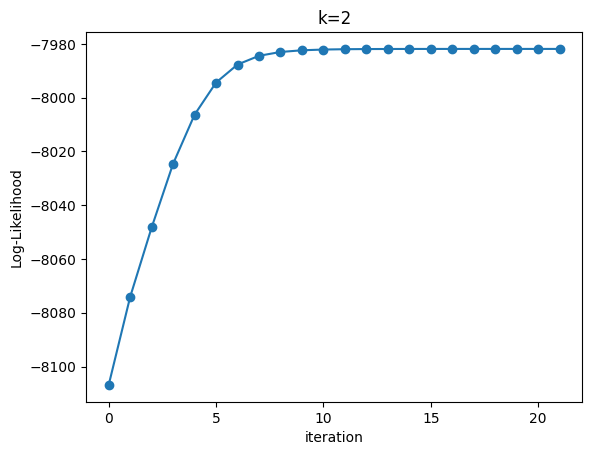

k=2	BIC=-8052.0416	logP(X|θ)=-7981.8532


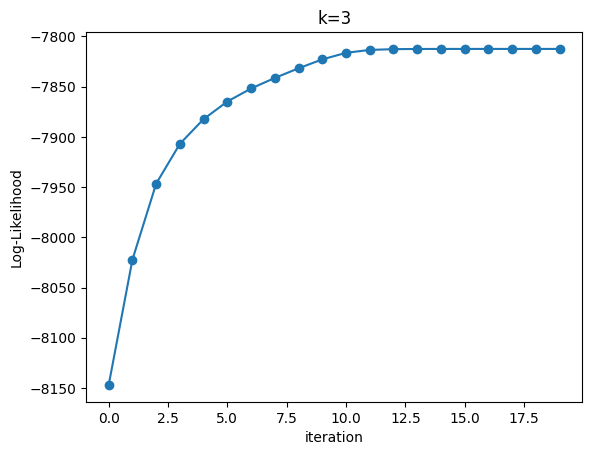

k=3	BIC=-7919.3844	logP(X|θ)=-7812.4306


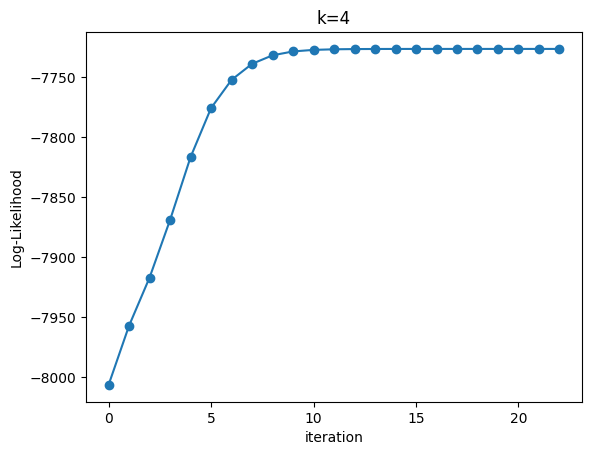

k=4	BIC=-7869.8688	logP(X|θ)=-7726.1497


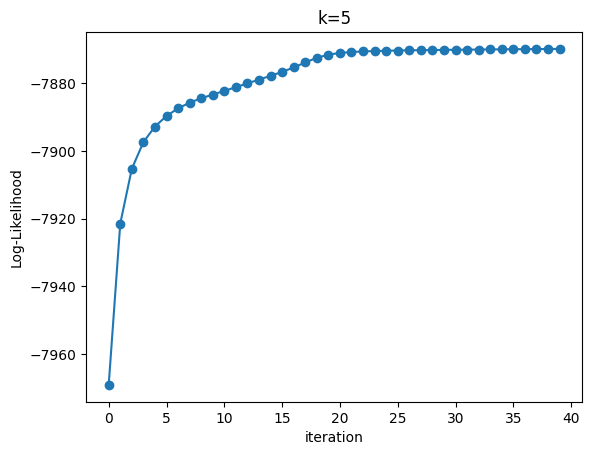

k=5	BIC=-8050.4121	logP(X|θ)=-7869.9276


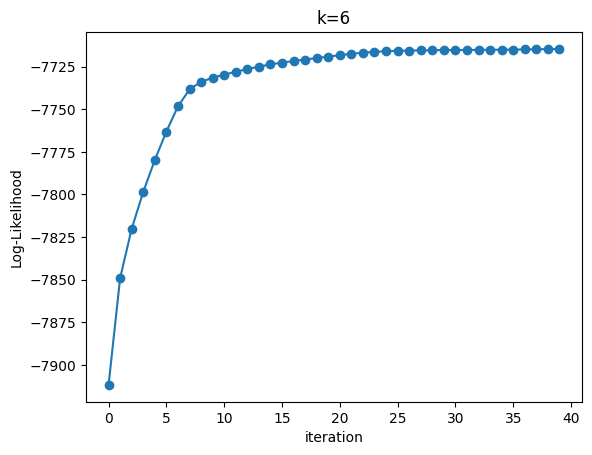

k=6	BIC=-7931.9206	logP(X|θ)=-7714.6707

Best model
k:		4
BIC:		-7869.8688
logP(X|θ):	-7726.1497


In [4]:
# load training set
train_df = pd.read_csv('train.csv')
print(f"train.csv loaded successfully. n={train_df.shape[0]}, d={train_df.shape[1]}")

# model selection using bayesian information score
seed_everything(9951)
candidate_categories = range(1, 7)
max_bic, best_k, best_gmm = -np.inf, None, None
for k in candidate_categories:
    gmm = GaussianMixtureModel(n_categories=k, n_features=train_df.shape[1])
    gmm.fit(train_df.values)
    ll = gmm.log_likelihood(train_df.values)
    bic_score = gmm.bic(train_df.values)
    print(f"k={k}\tBIC={bic_score:.4f}\tlogP(X|θ)={ll:.4f}")
    if bic_score > max_bic:
        max_bic = bic_score
        best_k = k
        best_gmm = gmm

# print training info
print()
print("Best model")
print(f"k:\t\t{best_k}")
print(f"BIC:\t\t{max_bic:.4f}")
print(f"logP(X|θ):\t{best_gmm.log_likelihood(train_df.values):.4f}")

### 4. Evaluation

To check if you did not break the API, you can use the training file to run the tests.

This is not meaningful for the evaluation of your model, as the true test set is hidden.

In [ ]:
# If test.csv does not exist copy train into test
!test -f test.csv || cp train.csv test.csv

In [ ]:
# load hidden test set ☠️
test_df = pd.read_csv('test.csv')
print(f"test.csv loaded successfully. n={test_df.shape[0]}, d={test_df.shape[1]}")

# print log-likelihood
test_log_likelihood = best_gmm.log_likelihood(test_df.values)
print(f"Log-likelihood of test data: {test_log_likelihood:.4f}")

# print parameters
print(f"k: {best_gmm.n_categories}")
print()
for cat_id in range(best_gmm.n_categories):
  print(f"π[{cat_id}]:", best_gmm._pi[cat_id])
  print(f"μ[{cat_id}]:", best_gmm._mu[cat_id])
  print(f"σ[{cat_id}]:", best_gmm._sigma[cat_id])
  print()